# RLN reference notebook

Trains a baseline `LSTMHistoric` model (MAE loss) with and without Regularization
Learning Networks (`regularization='rln(...)'`, see `src/utils/regularization.py`
and `agents.md`), and compares them — forecast accuracy, and the weight-sparsity
effect RLN induces.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.forecaster import Forecaster
from src.models import LSTMHistoric
from src.data import DataSource


In [2]:
HISTORIC_COLS = ['prcp', 'tmax', 'tmin', 'vp', 'srad']
TARGET_COL    = 'target'
HORIZON       = 7
SEQ_LEN       = 30
NODATA_VALUES = [-999]

train_source = DataSource(
    csv='data/data.csv',
    start='1980-01-01',
    end='2004-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)
val_source = DataSource(
    csv='data/data.csv',
    start='2005-01-01',
    end='2009-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)
test_source = DataSource(
    csv='data/data.csv',
    start='2010-01-01',
    end='2014-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)


## Train baseline (no regularization) and RLN models

Same architecture, loss, and hyperparameters throughout — `regularization` is the only difference.

In [3]:
MODEL_CONFIG = {
    'LSTM_hidden_size': 28,
    'LSTM_num_layers': 1,
    'dropout_rate': 0.0,
}
COMMON_KWARGS = dict(
    model=LSTMHistoric,
    model_config=MODEL_CONFIG,
    training_datasets=[train_source],
    validation_datasets=[val_source],
    historic_cols=HISTORIC_COLS,
    target_col=TARGET_COL,
    forecasting_horizon=HORIZON,
    historic_input_sequence_length=SEQ_LEN,
    loss_function='mae',
    validation_score='nse',
    validation_logging_criteria=['rmse'],
    minimize_validation_score=False,
    save_path='models',
    batch_size=256,
    number_of_epochs=50,
    use_torch_compile=False,
    save_weights_every_n_epochs=1,
)

fc_baseline = Forecaster(name='LSTMHistoric_mae_baseline', regularization=None, **COMMON_KWARGS)
fc_baseline.fit()


Best model saved → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_best.pt
Checkpoint saved  → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_epoch_1.pt
Epoch 1/50  train_loss=0.6747  val_loss=0.5807  val_score=0.0159  best=0.0159


Best model saved → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_best.pt
Checkpoint saved  → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_epoch_2.pt
Epoch 2/50  train_loss=0.5158  val_loss=0.4355  val_score=0.1834  best=0.1834


Best model saved → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_best.pt
Checkpoint saved  → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_epoch_3.pt
Epoch 3/50  train_loss=0.3998  val_loss=0.3546  val_score=0.4393  best=0.4393


Best model saved → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_best.pt
Checkpoint saved  → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_epoch_4.pt
Epoch 4/50  train_loss=0.3099  val_loss=0.2994  val_score=0.6127  best=0.6127


Best model saved → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_best.pt
Checkpoint saved  → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_epoch_5.pt
Epoch 5/50  train_loss=0.2693  val_loss=0.2792  val_score=0.6768  best=0.6768


...

Checkpoint saved  → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_epoch_46.pt
Epoch 46/50  train_loss=0.1783  val_loss=0.2323  val_score=0.7939  best=0.8079


Checkpoint saved  → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_epoch_47.pt
Epoch 47/50  train_loss=0.1771  val_loss=0.2302  val_score=0.8042  best=0.8079


Checkpoint saved  → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_epoch_48.pt
Epoch 48/50  train_loss=0.1757  val_loss=0.2350  val_score=0.7960  best=0.8079


Checkpoint saved  → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_epoch_49.pt
Epoch 49/50  train_loss=0.1757  val_loss=0.2327  val_score=0.7856  best=0.8079


Checkpoint saved  → models/LSTMHistoric_mae_baseline/model_LSTMHistoric_mae_baseline_epoch_50.pt
Epoch 50/50  train_loss=0.1731  val_loss=0.2387  val_score=0.7817  best=0.8079


In [4]:
fc_rln = Forecaster(name='LSTMHistoric_mae_rln', regularization='rln(theta=-8.0)', **COMMON_KWARGS)
fc_rln.fit()


Best model saved → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_best.pt
Checkpoint saved  → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_epoch_1.pt
Epoch 1/50  train_loss=0.6831  val_loss=0.6156  val_score=0.0197  best=0.0197


Best model saved → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_best.pt
Checkpoint saved  → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_epoch_2.pt
Epoch 2/50  train_loss=0.5516  val_loss=0.4982  val_score=0.0366  best=0.0366


Best model saved → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_best.pt
Checkpoint saved  → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_epoch_3.pt
Epoch 3/50  train_loss=0.4547  val_loss=0.3897  val_score=0.3359  best=0.3359


Best model saved → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_best.pt
Checkpoint saved  → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_epoch_4.pt
Epoch 4/50  train_loss=0.3405  val_loss=0.3204  val_score=0.5597  best=0.5597


Best model saved → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_best.pt
Checkpoint saved  → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_epoch_5.pt
Epoch 5/50  train_loss=0.2891  val_loss=0.2917  val_score=0.6476  best=0.6476


...

Checkpoint saved  → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_epoch_46.pt
Epoch 46/50  train_loss=0.2114  val_loss=0.2415  val_score=0.7635  best=0.7971


Checkpoint saved  → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_epoch_47.pt
Epoch 47/50  train_loss=0.2123  val_loss=0.2371  val_score=0.7777  best=0.7971


Checkpoint saved  → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_epoch_48.pt
Epoch 48/50  train_loss=0.2107  val_loss=0.2422  val_score=0.7756  best=0.7971


Checkpoint saved  → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_epoch_49.pt
Epoch 49/50  train_loss=0.2105  val_loss=0.2382  val_score=0.7651  best=0.7971


Checkpoint saved  → models/LSTMHistoric_mae_rln/model_LSTMHistoric_mae_rln_epoch_50.pt
Epoch 50/50  train_loss=0.2104  val_loss=0.2392  val_score=0.7711  best=0.7971


## Weight-magnitude comparison

Does RLN actually drive weights toward zero more aggressively than an unregularized baseline?

baseline (no regularization): 0.6% of weights below 0.001
RLN: 75.0% of weights below 0.001


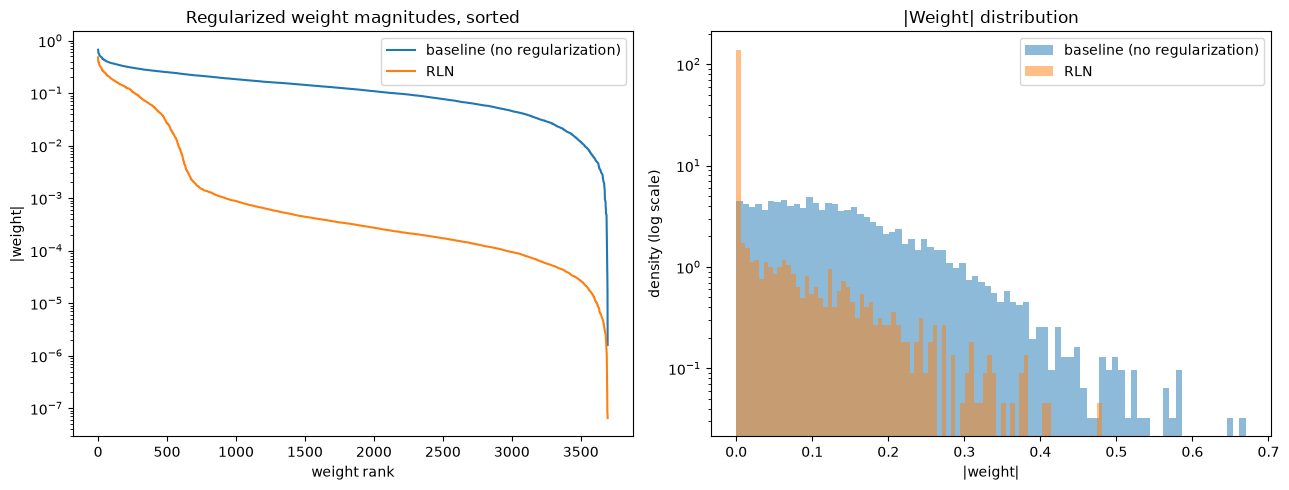

In [5]:
def plot_weight_magnitudes(models: dict, threshold: float = 1e-3):
    """Sorted (descending) |weight| curve (left) and a histogram of |weight| values
    (right) for each model's regularized weights. Flattens every tensor in
    `fc._regularized_weights` into one array per model. Also prints the fraction of
    weights below `threshold` per model, as a plain sparsity indicator.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for label, fc in models.items():
        w_abs = torch.cat([p.detach().abs().flatten() for p in fc._regularized_weights])
        w_sorted = w_abs.sort(descending=True).values.cpu().numpy()
        axes[0].plot(w_sorted, label=label)
        axes[1].hist(w_abs.cpu().numpy(), bins=80, density=True, alpha=0.5, label=label)
        print(f"{label}: {(w_abs < threshold).float().mean().item():.1%} of weights below {threshold}")

    axes[0].set_yscale('log')
    axes[0].set_xlabel('weight rank')
    axes[0].set_ylabel('|weight|')
    axes[0].set_title('Regularized weight magnitudes, sorted')
    axes[0].legend()

    axes[1].set_yscale('log')
    axes[1].set_xlabel('|weight|')
    axes[1].set_ylabel('density (log scale)')
    axes[1].set_title('|Weight| distribution')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_weight_magnitudes({'baseline (no regularization)': fc_baseline, 'RLN': fc_rln})


## Training diagnostics

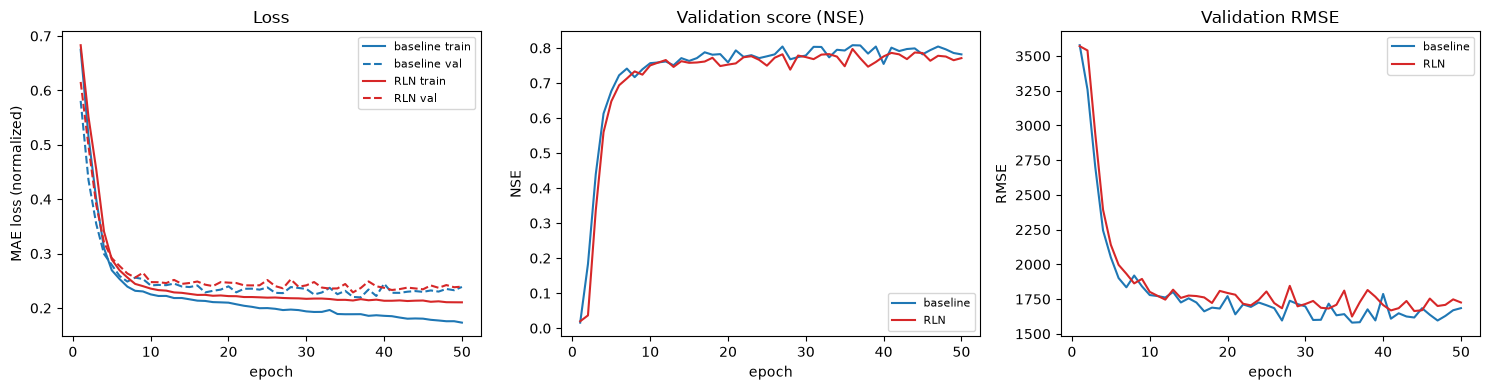

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [('baseline', fc_baseline, 'tab:blue'), ('RLN', fc_rln, 'tab:red')]

for label, m, color in models:
    ep = np.arange(1, len(m.loss_log) + 1)
    axes[0].plot(ep, m.loss_log, color=color, label=f'{label} train')
    axes[0].plot(ep, m.val_log_aggregated['mean']['loss'], color=color, linestyle='--', label=f'{label} val')
    axes[1].plot(ep, m.val_log_aggregated['mean']['val_score'], color=color, label=label)
    axes[2].plot(ep, m.val_log_aggregated['mean']['RMSE'], color=color, label=label)

axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MAE loss (normalized)')
axes[0].set_title('Loss'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('NSE')
axes[1].set_title('Validation score (NSE)'); axes[1].legend(fontsize=8)
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('RMSE')
axes[2].set_title('Validation RMSE'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Evaluation on `test_source`

In [7]:
from src.data.timeseries_dataset import TimeSeriesDataset
from src.data.normalization import _read_1d_df

preds_baseline = fc_baseline.predict(test_source, batch_size=256)
preds_rln = fc_rln.predict(test_source, batch_size=256)
y_pred_baseline = preds_baseline.squeeze(-1)
y_pred_rln = preds_rln.squeeze(-1)

# target_col doesn't affect which windows get built (only x_h/x_f NaN does), so this
# dataset covers the exact same windows as predict()'s internal one — built here only
# to read off the (source_idx, t) index for date alignment, not to run the model
test_ds = TimeSeriesDataset(
    sources=[test_source],
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    historic_cols=HISTORIC_COLS,
    future_cols=[],
    norm_stats=fc_baseline.norm_stats,
    target_col=TARGET_COL,
)
test_df = _read_1d_df(test_source)
t_values = np.array([t for _, t in test_ds._index])
y_true = np.stack([test_df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_values])

def lead_dates(lead):
    return test_df.index[t_values + SEQ_LEN + (lead - 1)]

print(f'Evaluated {y_true.shape[0]} windows over a {y_true.shape[1]}-day horizon on test_source')


Evaluated 1789 windows over a 7-day horizon on test_source


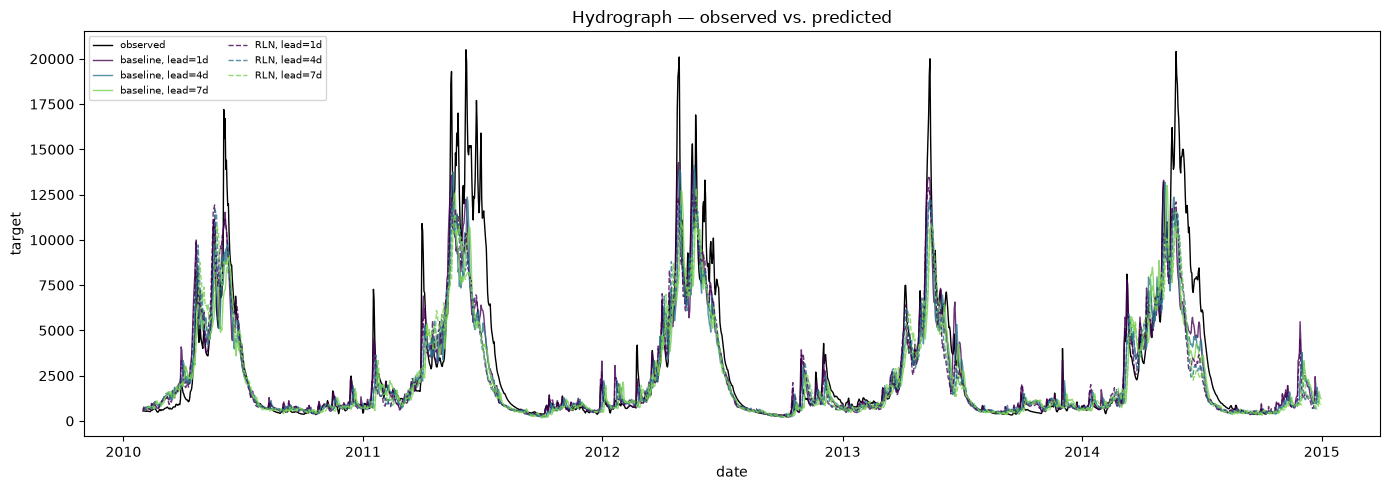

In [8]:
LEADS_TO_SHOW = [1, 4, 7]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lead_dates(1), y_true[:, 0], color='black', lw=1, label='observed')
colors = plt.cm.viridis(np.linspace(0, 0.8, len(LEADS_TO_SHOW)))
model_preds = [('baseline', y_pred_baseline, '-'), ('RLN', y_pred_rln, '--')]
for label, y_p, ls in model_preds:
    for lead, c in zip(LEADS_TO_SHOW, colors):
        dates = test_df.index[t_values + SEQ_LEN + (lead - 1)]
        ax.plot(dates, y_p[:, lead - 1], color=c, lw=1, alpha=0.8, linestyle=ls, label=f'{label}, lead={lead}d')
ax.set_xlabel('date'); ax.set_ylabel(TARGET_COL)
ax.set_title('Hydrograph — observed vs. predicted')
ax.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()


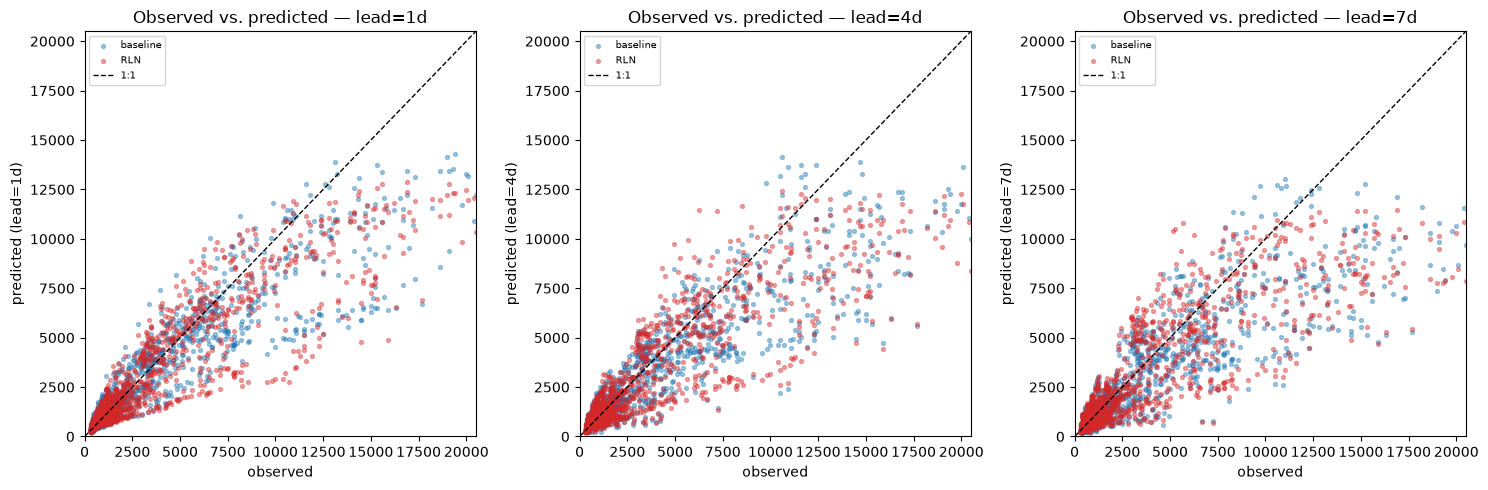

In [9]:
LEADS_TO_SHOW = [1, 4, 7]
model_preds = [('baseline', y_pred_baseline, 'tab:blue'), ('RLN', y_pred_rln, 'tab:red')]

fig, axes = plt.subplots(1, len(LEADS_TO_SHOW), figsize=(5 * len(LEADS_TO_SHOW), 5))
lims = [0, np.nanmax([np.nanmax(y_true)] + [np.nanmax(yp) for _, yp, _ in model_preds])]

for ax, lead in zip(axes, LEADS_TO_SHOW):
    for label, yp, color in model_preds:
        x = y_true[:, lead - 1]
        y = yp[:, lead - 1]
        ax.scatter(x, y, s=8, alpha=0.4, color=color, label=label)
    ax.plot(lims, lims, color='black', lw=1, linestyle='--', label='1:1')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('observed'); ax.set_ylabel(f'predicted (lead={lead}d)')
    ax.set_title(f'Observed vs. predicted — lead={lead}d')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


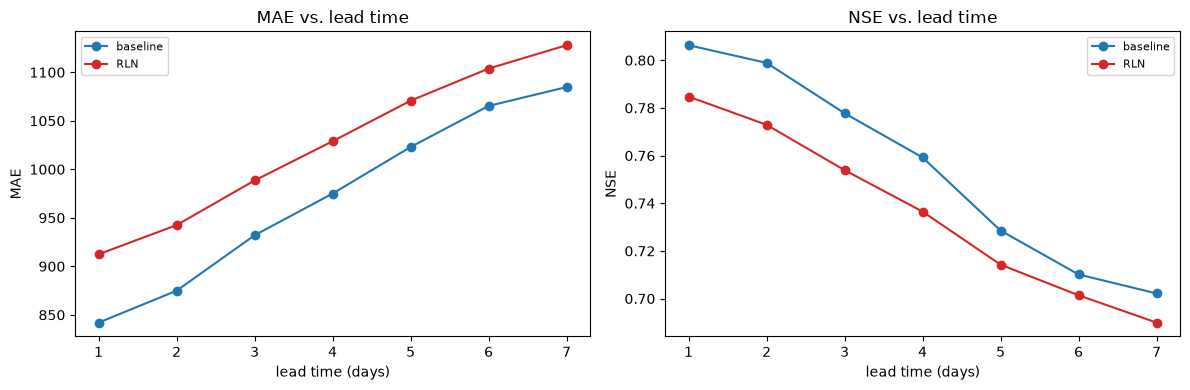

In [10]:
from src.utils.scores_and_losses import NSE

_nse_metric = NSE()

def nse(obs, pred):
    mask = ~np.isnan(obs) & ~np.isnan(pred)
    return _nse_metric(torch.tensor(pred[mask])[:, None], torch.tensor(obs[mask])[:, None]).item()

leads = np.arange(1, HORIZON + 1)
model_preds = [('baseline', y_pred_baseline, 'tab:blue'), ('RLN', y_pred_rln, 'tab:red')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, yp, color in model_preds:
    mae_per_lead = [np.nanmean(np.abs(y_true[:, i] - yp[:, i])) for i in range(HORIZON)]
    nse_per_lead = [nse(y_true[:, i], yp[:, i]) for i in range(HORIZON)]
    axes[0].plot(leads, mae_per_lead, marker='o', color=color, label=label)
    axes[1].plot(leads, nse_per_lead, marker='o', color=color, label=label)

axes[0].set_xlabel('lead time (days)'); axes[0].set_ylabel('MAE')
axes[0].set_title('MAE vs. lead time'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('lead time (days)'); axes[1].set_ylabel('NSE')
axes[1].set_title('NSE vs. lead time'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
